# Итоговый проект: кредитный скоринг

**Тема:** прогноз дефолта клиента по кредитной карте (`default payment next month`).

**Источник данных:** Kaggle — `narayanach/default-of-credit-card-clients` (из `FINAL_PROJECT_TOPIC.md`).

**Формат задачи:** бинарная классификация.

**Цель:** построить и сравнить модели, выбрать финальную модель по качеству и интерпретировать факторы риска.

## Структура работы

1. Постановка задачи и критерии качества.
2. Загрузка и первичная проверка данных.
3. Предобработка, очистка и заполнение пропусков.
4. Фиче-инжениринг и обоснование признаков.
5. Обучение baseline и нелинейной модели.
6. Метрики на train/validation/test.
7. Борьба с переобучением и итоговые выводы.

In [94]:
from pathlib import Path
import os
import shutil
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

## 1) Постановка задачи и критерии качества.

**Бизнес-контекст:** банку важно заранее оценивать риск дефолта клиента, чтобы управлять лимитами, политикой одобрения и мониторингом риска.

**ML-постановка:**
- тип задачи: бинарная классификация;
- целевая переменная: `default payment next month`;
- Значение = `1` - клиент допустит дефолт в следующем месяце.

**Основные метрики:** `ROC-AUC`, `Precision`, `Recall`, `F1`.

In [95]:
SEED = 42
np.random.seed(SEED)

## 2) Загрузка данных

Используется Kaggle-источник через `kagglehub`:
- датасет: `narayanach/default-of-credit-card-clients`;
- аутентификация: `KAGGLE_USERNAME` и `KAGGLE_KEY` в переменных окружения.

In [96]:
def load_credit_data() -> pd.DataFrame:
    """Загрузка датасета из Kaggle через переменные окружения."""
    username = os.getenv("KAGGLE_USERNAME")
    key = os.getenv("KAGGLE_KEY")

    if not username or not key:
        raise ValueError("Нужны переменные окружения KAGGLE_USERNAME и KAGGLE_KEY.")

    dataset_path = Path(
        kagglehub.dataset_download("narayanach/default-of-credit-card-clients")
    )

    if Path.cwd().name == "final_project":
        project_dir = Path.cwd()
    else:
        project_dir = Path.cwd() / "final_project"

    local_data_dir = project_dir / "data" / "kaggle" / "default-of-credit-card-clients"
    local_data_dir.mkdir(parents=True, exist_ok=True)
    shutil.copytree(dataset_path, local_data_dir, dirs_exist_ok=True)

    data_file = local_data_dir / "default of credit card clients.xls"
    if not data_file.exists():
        raise FileNotFoundError(f"Файл не найден: {data_file}")

    df = pd.read_excel(data_file)
    print(f"Данные прочитаны из: {data_file}")
    return df

In [97]:
df_raw = load_credit_data()

if str(df_raw.iloc[0, 0]).strip().upper() == "ID":
    df_raw = df_raw.iloc[1:].reset_index(drop=True)

clean_columns = [str(c).strip() for c in df_raw.columns]
if "Unnamed: 0" in clean_columns and "ID" not in clean_columns:
    clean_columns = ["ID" if c == "Unnamed: 0" else c for c in clean_columns]

df_raw.columns = clean_columns

df_raw.head()

Данные прочитаны из: C:\Users\Евгений\final_project\data\kaggle\default-of-credit-card-clients\default of credit card clients.xls


,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [98]:
print("Форма датасета:", df_raw.shape)
print("\nТипы данных:")
print(df_raw.dtypes.head(10))

missing_share = (df_raw.isna().mean() * 100).sort_values(ascending=False)
print("\nТоп-10 столбцов по доле пропусков (%):")
print(missing_share.head(10))

duplicates_count = df_raw.duplicated().sum()
print(f"\nКоличество полных дубликатов: {duplicates_count}")

Форма датасета: (30000, 25)

Типы данных:
ID    object
X1    object
X2    object
X3    object
X4    object
X5    object
X6    object
X7    object
X8    object
X9    object
dtype: object

Топ-10 столбцов по доле пропусков (%):
ID    0.0
X1    0.0
X2    0.0
X3    0.0
X4    0.0
X5    0.0
X6    0.0
X7    0.0
X8    0.0
X9    0.0
dtype: float64

Количество полных дубликатов: 0


## 3) Предобработка и очистка данных

Делаем простую подготовку данных:
- убираем дубликаты;
- выделяем целевую переменную;
- исключаем `ID` из признаков.

In [99]:
df = df_raw.copy()
df = df.drop_duplicates().reset_index(drop=True)

if "Y" in df.columns:
    target_col = "Y"
elif "default payment next month" in df.columns:
    target_col = "default payment next month"
else:
    raise ValueError("Не найдена целевая переменная (Y или default payment next month).")

id_col = "ID" if "ID" in df.columns else None

print("Целевая переменная:", target_col)
print("ID-колонка:", id_col)
print("Итоговая форма после очистки:", df.shape)

Целевая переменная: Y
ID-колонка: ID
Итоговая форма после очистки: (30000, 25)


Доли классов:
Y
0    0.7788
1    0.2212
Name: share, dtype: float64


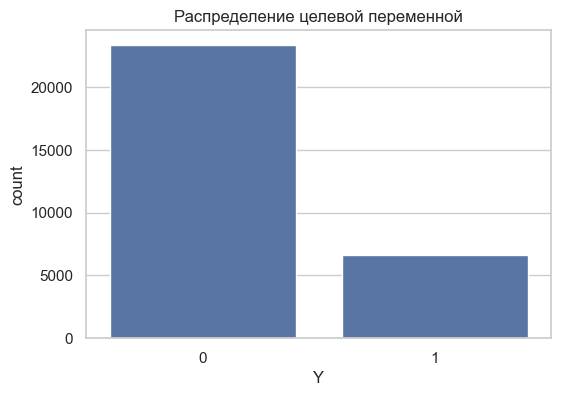

In [100]:
class_share = df[target_col].value_counts(normalize=True).rename("share")
print("Доли классов:")
print(class_share)

plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df)
plt.title("Распределение целевой переменной")
plt.show()

feature_candidates = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]
feature_candidates = [c for c in feature_candidates if c in df.columns]

if feature_candidates:
    df[feature_candidates].hist(figsize=(12, 8), bins=30)
    plt.suptitle("Распределения ключевых числовых признаков")
    plt.tight_layout()
    plt.show()

## 4) Фиче-инжениринг

Добавляем простые агрегаты по истории платежей и задолженности:
- среднее число месяцев просрочки и максимальная просрочка;
- средняя задолженность по выписке и средний фактический платеж;
- средняя доля использованного кредитного лимита.

In [101]:
def add_domain_features(input_df: pd.DataFrame) -> pd.DataFrame:
    df_fe = input_df.copy()

    pay_cols = [f"X{i}" for i in range(6, 12)]
    bill_cols = [f"X{i}" for i in range(12, 18)]
    amt_cols = [f"X{i}" for i in range(18, 24)]

    df_fe["pay_status_mean"] = df_fe[pay_cols].mean(axis=1)
    df_fe["pay_status_max"] = df_fe[pay_cols].max(axis=1)

    df_fe["bill_amt_mean"] = df_fe[bill_cols].mean(axis=1)
    df_fe["pay_amt_mean"] = df_fe[amt_cols].mean(axis=1)

    df_fe["utilization_mean"] = df_fe["bill_amt_mean"] / (df_fe["X1"].abs() + 1)

    return df_fe

In [102]:
drop_cols = [target_col]
if id_col is not None:
    drop_cols.append(id_col)

X = df.drop(columns=drop_cols)
y = df[target_col].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

X_train_fe = add_domain_features(X_train)
X_val_fe = add_domain_features(X_val)
X_test_fe = add_domain_features(X_test)

raw_duplicate_features = [f"X{i}" for i in range(6, 24)]
X_train_fe = X_train_fe.drop(columns=raw_duplicate_features, errors="ignore")
X_val_fe = X_val_fe.drop(columns=raw_duplicate_features, errors="ignore")
X_test_fe = X_test_fe.drop(columns=raw_duplicate_features, errors="ignore")

categorical_features = [c for c in ["X2", "X3", "X4"] if c in X_train_fe.columns]
numeric_features = [c for c in X_train_fe.columns if c not in categorical_features]

print("Shapes:")
print("Train:", X_train_fe.shape, y_train.shape)
print("Val:  ", X_val_fe.shape, y_val.shape)
print("Test: ", X_test_fe.shape, y_test.shape)
print("Categorical:", categorical_features)
print("Numeric count:", len(numeric_features))

Shapes:
Train: (18000, 10) (18000,)
Val:   (6000, 10) (6000,)
Test:  (6000, 10) (6000,)
Categorical: ['X2', 'X3', 'X4']
Numeric count: 7


## 5) Подготовка пайплайна и обучение моделей

Сравниваем:
- `LogisticRegression` как интерпретируемый baseline;
- `RandomForestClassifier` как нелинейную модель.

Обе модели обучаются в едином пайплайне предобработки.

In [103]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        C=0.5,
        random_state=SEED,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=30,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1,
    ),
}

pipelines = {
    name: Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    for name, model in models.items()
}


def eval_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

In [104]:
val_results = []
trained_models = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train_fe, y_train)
    val_proba = pipe.predict_proba(X_val_fe)[:, 1]
    metrics = eval_metrics(y_val, val_proba, threshold=0.5)
    metrics["model"] = name

    val_results.append(metrics)
    trained_models[name] = pipe

val_results_df = pd.DataFrame(val_results).sort_values("roc_auc", ascending=False)
val_results_df

,roc_auc,precision,recall,f1,model
1,0.766391,0.450441,0.616428,0.520522,RandomForest
0,0.715743,0.426533,0.608139,0.501398,LogisticRegression


Финальная модель по ROC-AUC на validation: RandomForest

## 6) Метрики на train / validation / test

Для риск-задачи порог `0.5` не всегда оптимален, поэтому подберём порог по валидационной выборке (максимум `F1`) и затем зафиксируем его для оценки на всех сплитах.

In [105]:
train_proba = final_pipe.predict_proba(X_train_fe)[:, 1]
val_proba = final_pipe.predict_proba(X_val_fe)[:, 1]
test_proba = final_pipe.predict_proba(X_test_fe)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)

# Для PR-кривой thresholds на 1 меньше, чем точек precision/recall
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Оптимальный порог по validation (max F1): {best_threshold:.4f}")
print(f"Average Precision (validation): {average_precision_score(y_val, val_proba):.4f}")

Оптимальный порог по validation (max F1): 0.5307
Average Precision (validation): 0.5041


In [106]:
split_scores = []
for split_name, y_true, y_proba in [
    ("train", y_train, train_proba),
    ("validation", y_val, val_proba),
    ("test", y_test, test_proba),
]:
    row = eval_metrics(y_true, y_proba, threshold=best_threshold)
    row["split"] = split_name
    split_scores.append(row)

split_scores_df = pd.DataFrame(split_scores)[["split", "roc_auc", "precision", "recall", "f1"]]
split_scores_df

,split,roc_auc,precision,recall,f1
0,train,0.805538,0.480780,0.637619,0.548203
1,validation,0.766391,0.466471,0.597589,0.523951
2,test,0.774391,0.463524,0.622457,0.531361


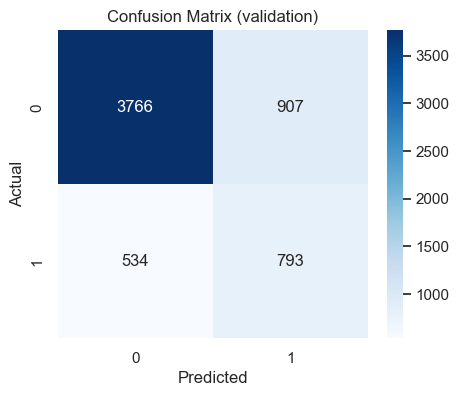

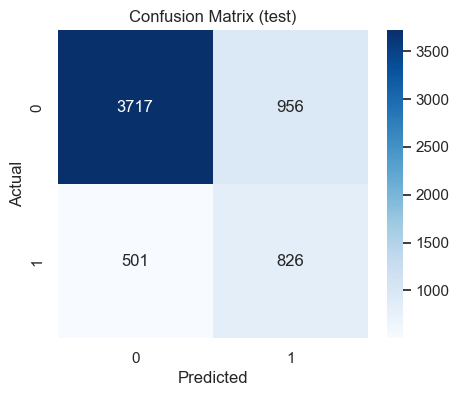

Classification report (test):
              precision    recall  f1-score   support

           0     0.8812    0.7954    0.8361      4673
           1     0.4635    0.6225    0.5314      1327

    accuracy                         0.7572      6000
   macro avg     0.6724    0.7089    0.6837      6000
weighted avg     0.7888    0.7572    0.7687      6000



In [107]:
# Матрицы ошибок на validation и test
for split_name, y_true, y_proba in [("validation", y_val, val_proba), ("test", y_test, test_proba)]:
    y_pred = (y_proba >= best_threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix ({split_name})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

print("Classification report (test):")
print(classification_report(y_test, (test_proba >= best_threshold).astype(int), digits=4))

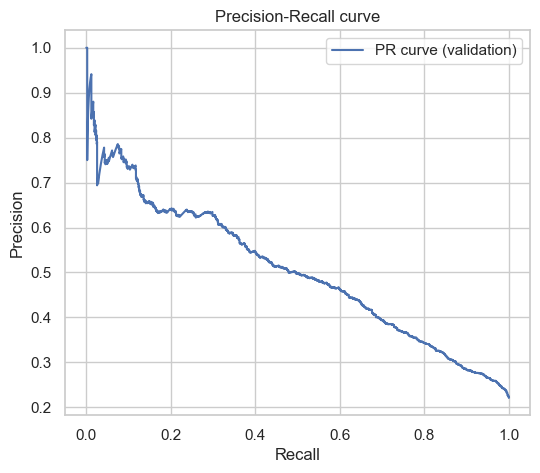

In [108]:
# Precision-Recall кривая на validation
plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, label="PR curve (validation)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend()
plt.show()

## 7) Проверка на переобучение

Проверяем стабильность модели по двум шагам:
1. Сравниваем метрики на train / validation / test.
2. Считаем 5-fold cross-validation на train.

Если test близок к validation и разброс CV небольшой, модель ведет себя стабильно.

In [109]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(
    final_pipe,
    X_train_fe,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
)

print(f"CV ROC-AUC (train, 5 folds): mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")

train_auc = roc_auc_score(y_train, train_proba)
val_auc = roc_auc_score(y_val, val_proba)
test_auc = roc_auc_score(y_test, test_proba)

print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Validation ROC-AUC: {val_auc:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")

CV ROC-AUC (train, 5 folds): mean=0.7750, std=0.0086
Train ROC-AUC: 0.8055
Validation ROC-AUC: 0.7664
Test ROC-AUC: 0.7744


## 8) Интерпретация факторов риска

Финальная модель — `RandomForest`, поэтому анализируем `feature_importances_`.
Ниже важности приводятся в бизнес-терминах и с пометкой источника признака:
- агрегат (`feature engineering`) или сырой признак;
- принадлежность к бизнес-группе (просрочки, счета, платежи и т.д.).

Так интерпретация становится прозрачной: видно, где модель опирается на агрегаты, а где на исходные коэффициенты (`X*`).

Топ-5 факторов по importance


,фича,importance
0,Максимальное число месяцев просрочки,0.357382
1,Среднее число месяцев просрочки,0.295351
2,Средний ежемесячный платёж ($),0.097438
3,Средняя доля кредитного лимита (%),0.073599
4,Средняя сумма долга,0.062534


Сырые факторы вне top-5 по importance


,сырая_фича_вне_top5,importance
5,размер выданного кредита ($),0.061702
6,возраст (годы),0.021700
7,образование,0.013278
8,пол,0.009337
9,семейное положение,0.007678


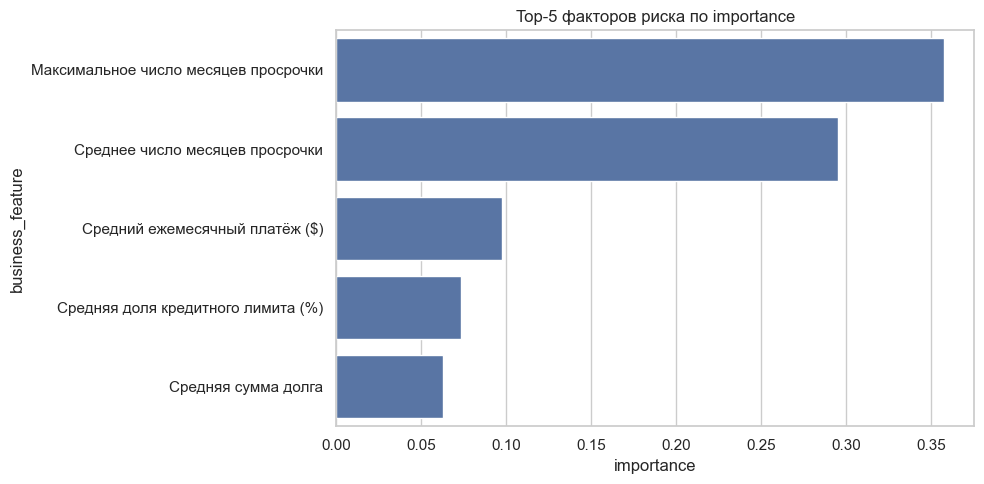

In [93]:
feature_names = final_pipe.named_steps["preprocess"].get_feature_names_out()
model_obj = final_pipe.named_steps["model"]

if hasattr(model_obj, "feature_importances_"):
    importance_values = model_obj.feature_importances_
elif hasattr(model_obj, "coef_"):
    importance_values = np.abs(model_obj.coef_[0])
else:
    raise ValueError("У финальной модели отсутствует атрибут важностей признаков.")

imp_df = pd.DataFrame(
    {"feature": feature_names, "importance": importance_values}
).sort_values("importance", ascending=False)

pay_status_features = [f"X{i}" for i in range(6, 12)]
bill_features = [f"X{i}" for i in range(12, 18)]
pay_features = [f"X{i}" for i in range(18, 24)]

aggregate_components_map = {
    "pay_status_mean": pay_status_features,
    "pay_status_max": pay_status_features,
    "bill_amt_mean": bill_features,
    "bill_amt_std": bill_features,
    "pay_amt_mean": pay_features,
    "pay_amt_std": pay_features,
    "utilization_mean": ["X1", *bill_features],
    "payment_coverage": [*bill_features, *pay_features],
}
aggregate_components_map.update(
    {
        f"repay_ratio_{i}": [f"X{11 + i}", f"X{17 + i}"]
        for i in range(1, 7)
    }
)

business_name_map = {
    "X1": "размер выданного кредита ($)",
    "X2": "пол",
    "X3": "образование",
    "X4": "семейное положение",
    "X5": "возраст (годы)",
    "X6": "статус погашения в сентябре",
    "X7": "статус погашения в августе",
    "X8": "статус погашения в июле",
    "X9": "статус погашения в июне",
    "X10": "статус погашения в мае",
    "X11": "статус погашения в апреле",
    "X12": "сумма задолженности по выписке в сентябре ($)",
    "X13": "сумма задолженности по выписке в августе ($)",
    "X14": "сумма задолженности по выписке в июле ($)",
    "X15": "сумма задолженности по выписке в июне ($)",
    "X16": "сумма задолженности по выписке в мае ($)",
    "X17": "сумма задолженности по выписке в апреле ($)",
    "X18": "сумма фактического платежа в сентябре ($)",
    "X19": "сумма фактического платежа в августе ($)",
    "X20": "сумма фактического платежа в июле ($)",
    "X21": "сумма фактического платежа в июне ($)",
    "X22": "сумма фактического платежа в мае (N$)",
    "X23": "сумма фактического платежа в апреле ($)",
    "pay_status_mean": "Среднее число месяцев просрочки",
    "pay_status_max": "Максимальное число месяцев просрочки",
    "bill_amt_mean": "Средняя сумма долга",
    "bill_amt_std": "изменчивость задолженности по выписке за апрель-сентябрь ($)",
    "pay_amt_mean": "Средний ежемесячный платёж ($)",
    "pay_amt_std": "изменчивость фактических платежей за апрель-сентябрь ($)",
    "utilization_mean": "Средняя доля кредитного лимита (%)",
    "payment_coverage": "доля задолженности, покрытая платежами за апрель-сентябрь",
}

month_name_map = {
    1: "сентябрь",
    2: "август",
    3: "июль",
    4: "июнь",
    5: "май",
    6: "апрель",
}
for idx, month_name in month_name_map.items():
    business_name_map[f"repay_ratio_{idx}"] = f"доля погашения счета за {month_name}"


def extract_raw_feature_name(feature_name: str) -> str:
    if "__" in feature_name:
        return feature_name.split("__", 1)[1]
    return feature_name


def extract_base_feature_name(raw_feature: str) -> str:
    if raw_feature.startswith("X") and "_" in raw_feature:
        return raw_feature.split("_", 1)[0]
    return raw_feature


def to_business_name(feature_name: str) -> str:
    return business_name_map.get(feature_name, feature_name)


imp_df = imp_df.copy()
imp_df["raw_feature"] = imp_df["feature"].map(extract_raw_feature_name)
imp_df["base_feature"] = imp_df["raw_feature"].map(extract_base_feature_name)
imp_df["source_type"] = imp_df["base_feature"].map(
    lambda x: "агрегат" if x in aggregate_components_map else "сырой"
)

factor_imp_df = (
    imp_df.groupby(["base_feature", "source_type"], as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
factor_imp_df["business_feature"] = factor_imp_df["base_feature"].map(to_business_name)

raw_importance_map = (
    factor_imp_df[factor_imp_df["source_type"] == "сырой"]
    .set_index("base_feature")["importance"]
    .to_dict()
)


def get_top_raw_component(aggregate_feature: str):
    components = aggregate_components_map.get(aggregate_feature, [])
    if not components:
        return pd.NA, pd.NA

    available_components = [
        (feature, raw_importance_map[feature])
        for feature in components
        if feature in raw_importance_map
    ]
    if not available_components:
        return "сырой фактор не входит в модель", pd.NA

    best_feature, best_importance = max(
        available_components,
        key=lambda item: item[1],
    )
    return to_business_name(best_feature), best_importance


top5_factors = factor_imp_df.head(5).copy()
top5_factors[["top_raw_feature_in_aggregate", "top_raw_feature_importance"]] = top5_factors[
    "base_feature"
].apply(lambda feature: pd.Series(get_top_raw_component(feature)))
top5_factors.loc[
    top5_factors["source_type"] == "сырой",
    ["top_raw_feature_in_aggregate", "top_raw_feature_importance"],
] = pd.NA

top5_base_features = set(top5_factors["base_feature"])
raw_low_impact_df = factor_imp_df[
    (factor_imp_df["source_type"] == "сырой")
    & (~factor_imp_df["base_feature"].isin(top5_base_features))
].sort_values("importance", ascending=False)

print("Топ-5 факторов по importance")
display(
    top5_factors[["business_feature", "importance"]].rename(
        columns={
            "business_feature": "фича",
            "importance": "importance",
        }
    )
)

print("Сырые факторы вне top-5 по importance")
display(
    raw_low_impact_df[["business_feature", "importance"]].rename(
        columns={
            "business_feature": "сырая_фича_вне_top5",
            "importance": "importance",
        }
    )
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top5_factors, x="importance", y="business_feature")
plt.title("Top-5 факторов риска по importance")
plt.tight_layout()
plt.show()

## 9) Итоговые бизнес-выводы

1. В работе были обучены и сравнены две модели: `LogisticRegression` как базовая интерпретируемая модель и `RandomForest` как более гибкая нелинейная модель.
2. По метрике `ROC-AUC` лучшей моделью оказался `RandomForest`, поэтому именно он выбран как итоговая модель для оценки и ранжирования риска дефолта.
3. Дополнительно для выбранной модели был проведён анализ важности признаков, чтобы понять, какие характеристики клиента сильнее всего влияют на прогноз.
4. Наибольший вклад в прогноз дают агрегированные признаки, которые описывают платёжную дисциплину и долговую нагрузку клиента за несколько месяцев: `Максимальное число месяцев просрочки`, `Среднее число месяцев просрочки`, `Средний ежемесячный платёж ($)`, `Средняя доля кредитного лимита (%)`, `Средняя сумма долга`.
5. Это означает, что для практической оценки риска особенно важны не отдельные значения за один месяц, а общее поведение клиента за период.
6. В итоговой таблице для каждого важного агрегированного признака дополнительно показан наиболее сильный исходный признак, чтобы сохранить связь результата модели с исходными данными.
7. С практической точки зрения модель можно использовать как основу для мониторинга риска, а следующим шагом может быть выбор рабочего порога отсечения с учётом стоимости ошибок: пропуска дефолта и ложного срабатывания.